# Alpha Research Pipeline

7-step template: Signal -> Rank -> Position -> Shift -> Returns -> Combine -> Evaluate

Uses `data_loader.py` and `alpha_utils.py`
In this notebook : load data -> define signal -> call `evaluate_alpha()` -> plot.

In [1]:
import matplotlib.pyplot as plt
from data_loader import load_data, get_close_prices, get_volume, get_open_prices
from alpha_utils import evaluate_alpha
from alpha_utils import SPLIT_DATE
from alpha_utils import ts_rank, ts_min, ts_max
from alpha_utils import rolling_corr
from alpha_utils import get_liquidity_universe
from alpha_utils import plot_alpha
import numpy as np 
import pandas as pd 
import warnings
from scipy.stats import ConstantInputWarning
warnings.filterwarnings('ignore', category=ConstantInputWarning)

data = load_data()
close = get_close_prices(data)
open_px = get_open_prices(data)
volume = get_volume(data)
n_stocks = close.shape[1]
print(close.shape)

Loading cached data from data/sp500_5y.parquet
(1255, 503)


In [2]:
print(data.columns.get_level_values(1).unique())

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='object', name='Price')


## 12-1 Month Momentum
                

In [3]:
close = get_close_prices(data)

In [4]:
signal = (close.shift(21)/close.shift(252)) - 1

In [5]:
universe = get_liquidity_universe(close, volume, n_stocks=100, direction='largest')
signal_subset = signal[universe]
close_subset = close[universe]

In [6]:
results_mm = evaluate_alpha(signal_subset, close_subset, n_stocks=100)
print("Train Sharpe:", results_mm["train_sharpe"])
print("IC mean:", results_mm["train_ic"])

Train Sharpe: 0.9735228558744612
IC mean: 0.02486955901044087


### OOS Train and Test for 12-1 Month Momentum

In [7]:
results_mm = evaluate_alpha(signal_subset, close_subset, n_stocks=100)
print("train_sharpe:", results_mm['train_sharpe'])
print("train_ic:", results_mm["train_ic"])
print("test_sharpe:", results_mm['test_sharpe'])
print("test_ic:", results_mm["test_ic"])

train_sharpe: 0.9735228558744612
train_ic: 0.02486955901044087
test_sharpe: 0.8041657656184061
test_ic: 0.02679627995669327


### Plot 12-1 Month Momentum

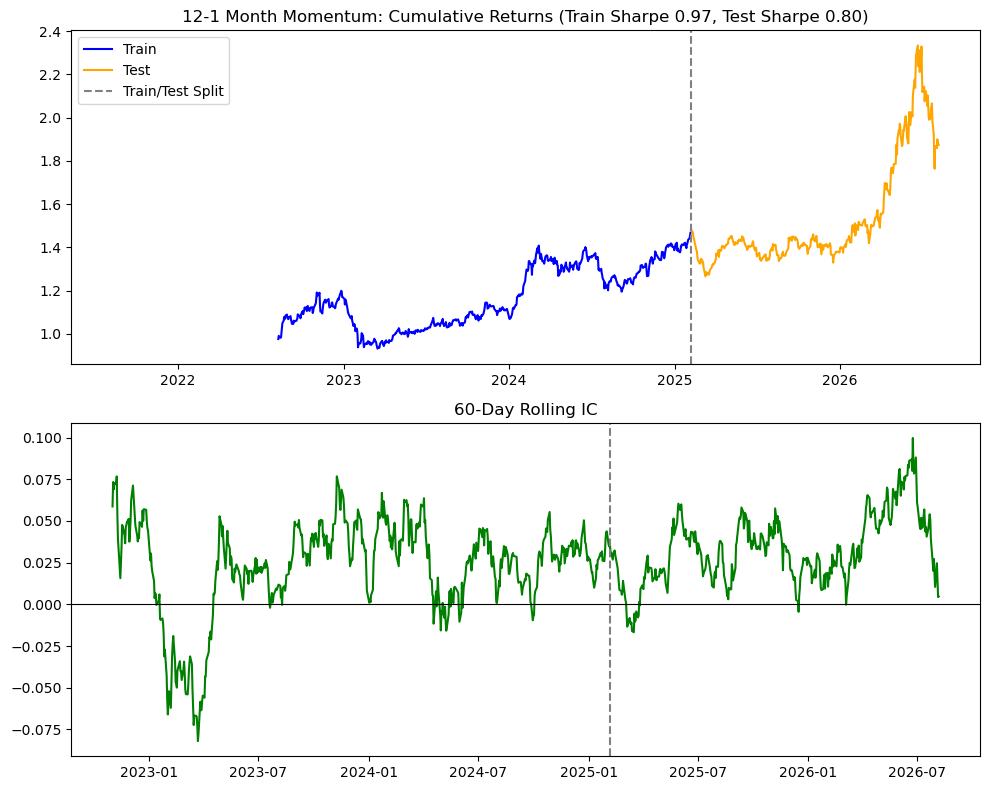

In [8]:
plot_alpha(results_mm, SPLIT_DATE, "12-1 Month Momentum")

### 12-1 Month Momentum Summary

Signal : 11 month returns (252-day lookback), skipping the most recent month (21-days to avoid short-term reversal contamination)

Universe : Top 100 stocks (large-cap within S&P 500)

Weighting : rank strength

Train : Sharpe = 0.9735 | IC Mean = 0.0248

Test OOS : Sharpe = 0.8041 | IC mean = 0.0267


## Short Term Reversal (1 week/ 1 month) 

In [9]:
def short_term_reversal(close, window=21, skip=0):
    past_ret = close.pct_change(window, fill_method=None)

    if skip > 0:
        past_ret = past_ret.shift(skip)
    signal_str = -past_ret
    return signal_str 

windows = [5, 21]
skip = [0, 1]
signal_dict = {}

for w in windows:
    for s in skip:
        signal_dict[(w, s)] = short_term_reversal(close, window=w, skip=s)

In [10]:
universe = get_liquidity_universe(close, volume, n_stocks=200, direction='smallest')
signal_str_subset = signal_dict[(w, s)][universe]
close_subset = close[universe]

In [11]:
results_str = {}
for (w, s), sig in signal_dict.items():
    signal_subset = sig[universe]
    results_str[(w, s)] = evaluate_alpha(signal_subset, close_subset, n_stocks=200)
    print(f'window = {w}, skip={s}')
    print("train sharpe:", results_str[(w, s)]["train_sharpe"])
    print("IC mean:", results_str[(w, s)]["train_ic"])
    print()

window = 5, skip=0
train sharpe: 1.251958153660772
IC mean: 0.01858666573784819

window = 5, skip=1
train sharpe: 0.7663218008854921
IC mean: 0.011354445719799109

window = 21, skip=0
train sharpe: 1.200330523352675
IC mean: 0.011666110038079535

window = 21, skip=1
train sharpe: 0.9194210609297107
IC mean: 0.005674214260344797



### OOS Train/Test on Short Term Reversal

In [12]:
signal_5_1 = signal_dict[(5, 1)]
signal_subset = signal_5_1[universe]
close_subset = close[universe]

results_5_1 = evaluate_alpha(signal_subset, close_subset, n_stocks=200)

print('window=5', 'skip=1')
print("train_sharpe:", results_5_1['train_sharpe'])
print("train_ic:", results_5_1["train_ic"])
print("test_sharpe:", results_5_1['test_sharpe'])
print("test_ic:", results_5_1["test_ic"])

window=5 skip=1
train_sharpe: 0.7663218008854921
train_ic: 0.011354445719799109
test_sharpe: 0.19083824915440636
test_ic: 0.006311508970937542


### Plot Short Term Reversal (1 week/ 1 month)

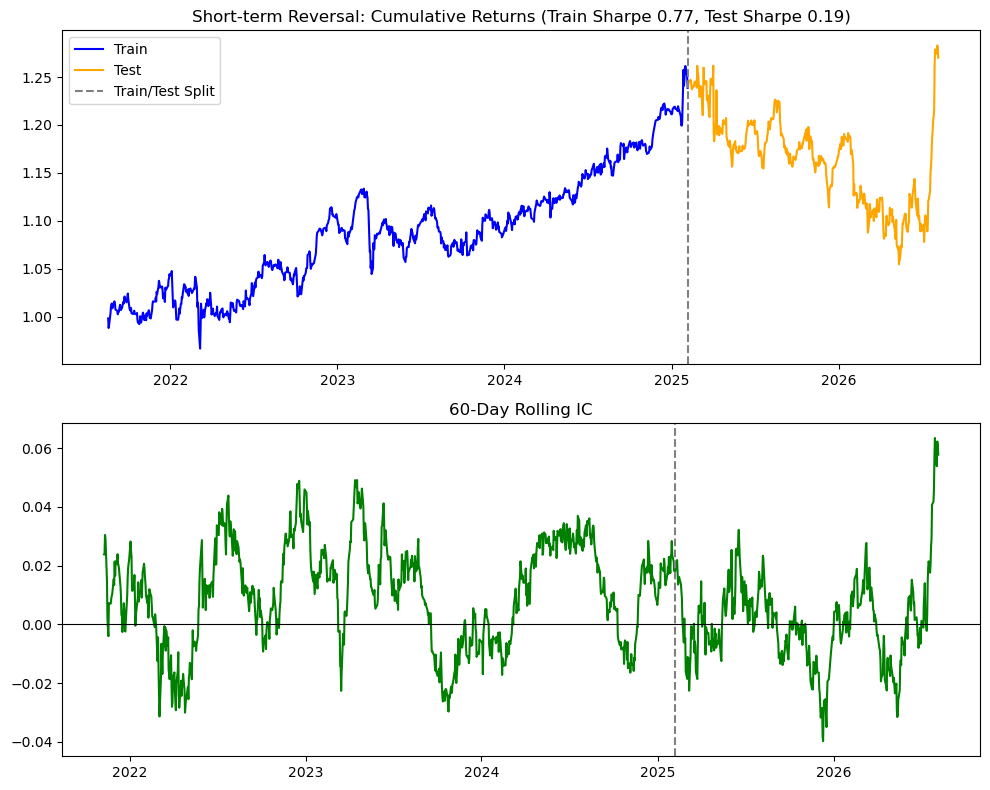

In [13]:
plot_alpha(results_5_1, SPLIT_DATE, "Short-term Reversal")

### Short Term Reversal Summary

Signal : Past returns over short window (ex: 5 trade days, 21 trade days)

Skip-day test: skip=1 removes next-days bid-ask bounce.

5d train sharpe drops 1.25 (skip=0) -> 0.77 (skip=1)

confirming raw signal is partly-bounce noise not pure overeaction.

Only (5d, skip 1) tested OOS

Universe : Bottom 200 stocks (small-cap within S&P 500)

Weighting : rank strength

Train : Sharpe = 0.766 | IC Mean = 0.011

Test OOS : Sharpe = 0.190 | IC mean = 0.006

IC is cyclic (bursts ~0.05, flat near 0) in both train and test signal works intermittently, not uniformly over time
